In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 1- Loading Data

In [2]:
top_impressions = pd.read_csv('top_impressions.csv', encoding='utf-8')
top_engagements = pd.read_csv('top_engagements.csv', encoding='utf-8')
classified_posts = pd.read_csv('classified_posts.csv', encoding='utf-8')

In [3]:
top_impressions.head(3)

,id,post_publish_date,day_name,impressions
0,7426169034179547136,2026-02-08,Sunday,24049
1,7434855171056144384,2026-03-04,Wednesday,18207
2,7435367669677101056,2026-03-05,Thursday,7270


In [4]:
top_engagements.head(3)

,id,post_publish_date,day_name,engagements
0,7426169034179547136,2026-02-08,Sunday,340
1,7434855171056144384,2026-03-04,Wednesday,223
2,7435367669677101056,2026-03-05,Thursday,133


In [5]:
classified_posts.head()

,id,attachments,post_len,category,style
0,7426169034179547136,N,503,Tech & Educational Content,Professional
1,7434855171056144384,N,462,Career Advice & Mindset,Funny
2,7435367669677101056,Img,2528,Career Advice & Mindset,Funny
3,7436453754679263233,Vid,1508,Tech & Educational Content,Funny
4,7430597141343027200,Imgs,2829,Career Updates & Achievements,Personal


In [6]:
top_impressions.shape

(50, 4)

In [7]:
top_engagements.shape

(50, 4)

In [8]:
classified_posts.shape

(62, 5)

In [9]:
# merging top_impressions df with classified_posts df
top_impressions_classified = pd.merge(top_impressions, classified_posts, how='left', left_on='id', right_on='id')
# merging top_engagements df with classified_posts df
top_engagements_classified = pd.merge(top_engagements, classified_posts, how='left', left_on='id', right_on='id')

## 2- Assessing Data

In [10]:
# checking for null values
print('Impressions Null Values: ', top_impressions_classified.isnull().sum().sum())
print('Engagements Null Values: ', top_engagements_classified.isnull().sum().sum())

Impressions Null Values:  0
Engagements Null Values:  4


In [11]:
# checking for duplicated rows
print('Impressions Duplicated Rows: ', top_impressions_classified.duplicated().sum())
print('Engagements Duplicated Rows: ', top_engagements_classified.duplicated().sum())

Impressions Duplicated Rows:  0
Engagements Duplicated Rows:  0


## 3- EDA

### 3.1- Impressions & Engagements per Day of Week

In [12]:
top_impressions_classified.head(3)

,id,post_publish_date,day_name,impressions,attachments,post_len,category,style
0,7426169034179547136,2026-02-08,Sunday,24049,N,503,Tech & Educational Content,Professional
1,7434855171056144384,2026-03-04,Wednesday,18207,N,462,Career Advice & Mindset,Funny
2,7435367669677101056,2026-03-05,Thursday,7270,Img,2528,Career Advice & Mindset,Funny


In [13]:
# calculating average impressions per day of week
top_impressions_classified.groupby('day_name').impressions.mean().sort_values(ascending=False)

day_name
Sunday       4461.875000
Wednesday    2804.375000
Thursday     1614.714286
Tuesday       880.555556
Saturday      801.000000
Friday        786.400000
Monday        662.200000
Name: impressions, dtype: float64

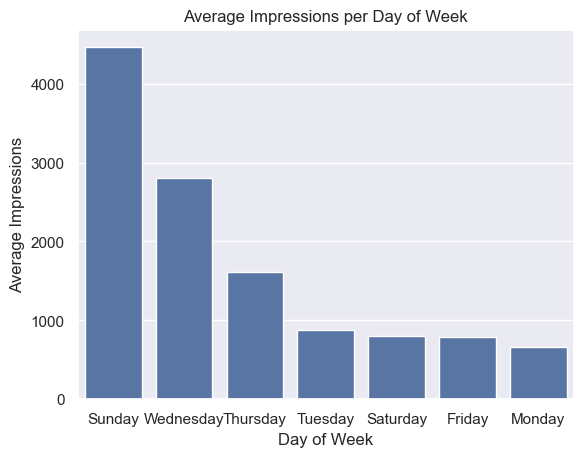

In [14]:
# plotting average impressions per day of week
plt.title('Average Impressions per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Impressions')
sns.barplot(top_impressions_classified.groupby('day_name').impressions.mean().sort_values(ascending=False));

In [15]:
# calculating average impressions per day of week
top_engagements_classified.groupby('day_name').engagements.mean().sort_values(ascending=False)

day_name
Sunday       58.875000
Wednesday    34.888889
Thursday     28.857143
Friday       18.750000
Tuesday      15.750000
Saturday     13.714286
Monday       12.000000
Name: engagements, dtype: float64

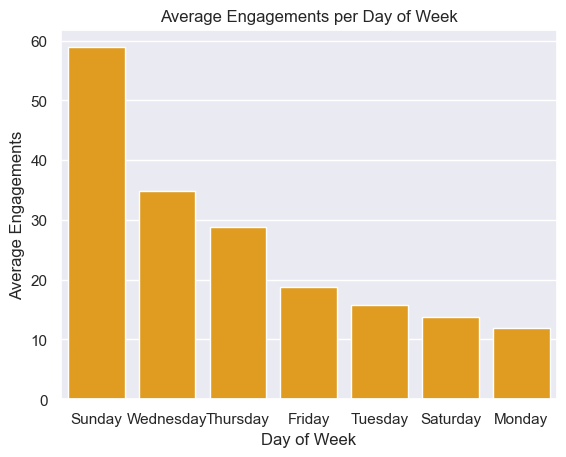

In [16]:
# plotting average engagements per day of week
plt.title('Average Engagements per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Engagements')
sns.barplot(top_engagements_classified.groupby('day_name').engagements.mean().sort_values(ascending=False), color='orange');

### 3.2- Impressions & Engagements VS Post Length

<Axes: xlabel='impressions', ylabel='post_len'>

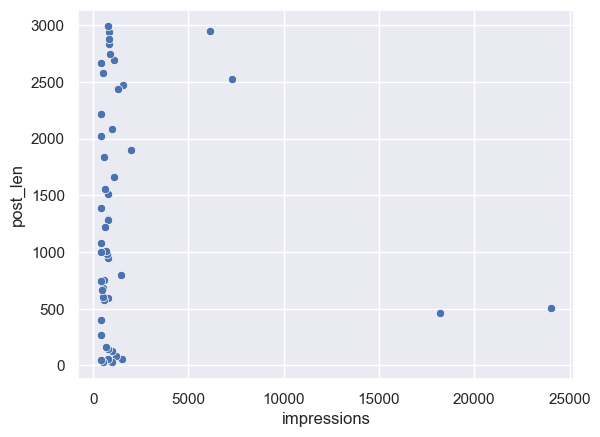

In [17]:
# plotting the relationship between impressions & post length
sns.scatterplot(x=top_impressions_classified.impressions, y=top_impressions_classified.post_len)

<Axes: xlabel='engagements', ylabel='post_len'>

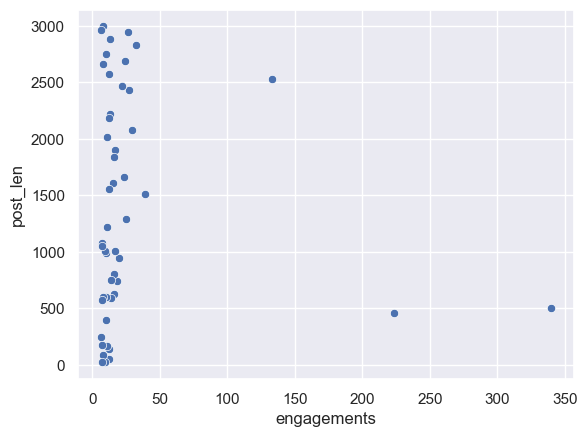

In [18]:
# plotting the relationship between engagement & post length
sns.scatterplot(x=top_engagements_classified.engagements, y=top_engagements_classified.post_len)

### 3.3- Impressions & Engagements per Attachment Type

In [19]:
# calculating average impressions for each attachment type
top_impressions_classified.groupby('attachments').impressions.mean().sort_values(ascending=False)

attachments
N        3977.692308
Vid      1334.090909
Img      1095.705882
Share     753.000000
Imgs      655.500000
Name: impressions, dtype: float64

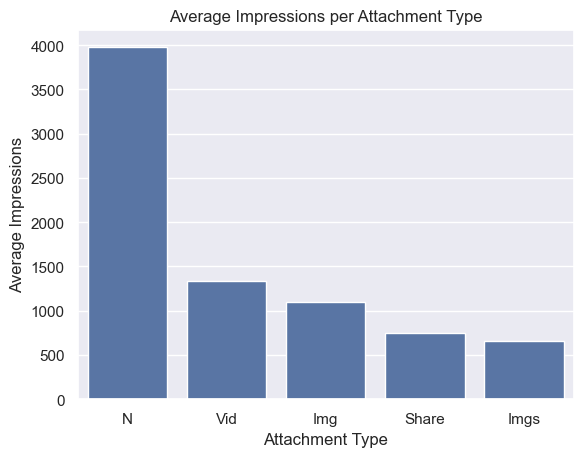

In [20]:
# plotting average impressions for each attachment type
plt.title('Average Impressions per Attachment Type')
plt.xlabel('Attachment Type')
plt.ylabel('Average Impressions')
sns.barplot(top_impressions_classified.groupby('attachments').impressions.mean().sort_values(ascending=False));

In [21]:
# calculating average engagements for each attachment type
top_engagements_classified.groupby('attachments').engagements.mean().sort_values(ascending=False)

attachments
N        56.750
Vid      20.625
Imgs     18.500
Img      17.800
Share    12.000
Name: engagements, dtype: float64

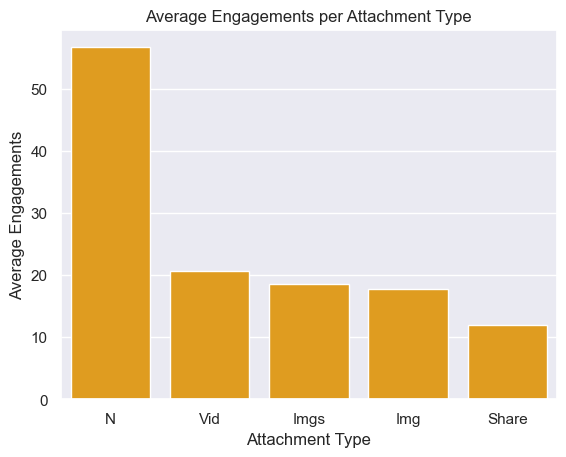

In [22]:
# plotting average engagements for each attachment type
plt.title('Average Engagements per Attachment Type')
plt.xlabel('Attachment Type')
plt.ylabel('Average Engagements')
sns.barplot(top_engagements_classified.groupby('attachments').engagements.mean().sort_values(ascending=False), color='orange');

### 3.4- Impressions & Engagements per Post Category

In [23]:
# calculating average impressions per post cateogry
top_impressions_classified.groupby('category').impressions.mean().sort_values(ascending=False)

category
Career Advice & Mindset          2384.866667
Tech & Educational Content       1706.625000
Career Updates & Achievements    1297.909091
Name: impressions, dtype: float64

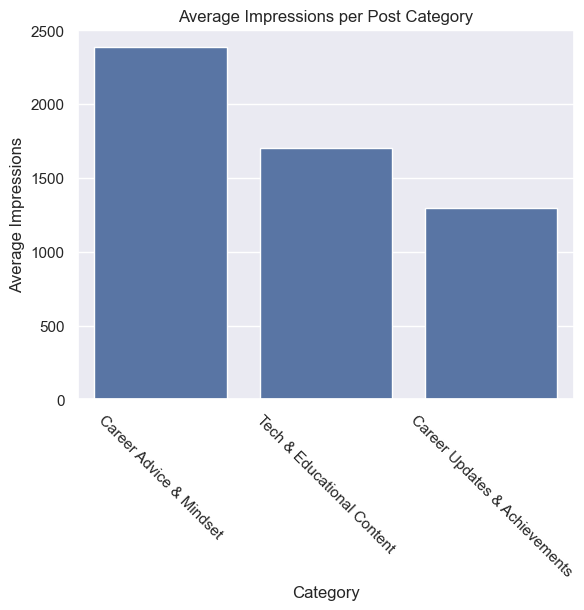

In [24]:
# plotting average impressions per post category
plt.title('Average Impressions per Post Category')
plt.xlabel('Category')
plt.ylabel('Average Impressions')
sns.barplot(top_impressions_classified.groupby('category').impressions.mean().sort_values(ascending=False))
plt.xticks(rotation=-45);

In [25]:
# calculating average engagements per post cateogry
top_engagements_classified.groupby('category').engagements.mean().sort_values(ascending=False)

category
Career Advice & Mindset          43.818182
Tech & Educational Content       24.366667
Career Updates & Achievements    18.625000
Name: engagements, dtype: float64

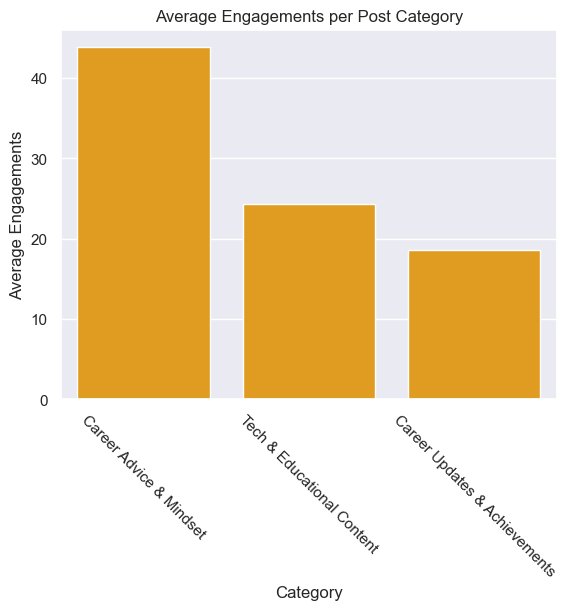

In [26]:
# plotting average engagements per post category
plt.title('Average Engagements per Post Category')
plt.xlabel('Category')
plt.ylabel('Average Engagements')
sns.barplot(top_engagements_classified.groupby('category').engagements.mean().sort_values(ascending=False), color='orange')
plt.xticks(rotation=-45);

### 3.5- Impressions & Engagements per Post Style

In [27]:
# calculating average impressions per post style
top_impressions_classified.groupby('style').impressions.mean().sort_values(ascending=False)

style
Professional    3069.538462
Funny           1785.619048
Personal         850.437500
Name: impressions, dtype: float64

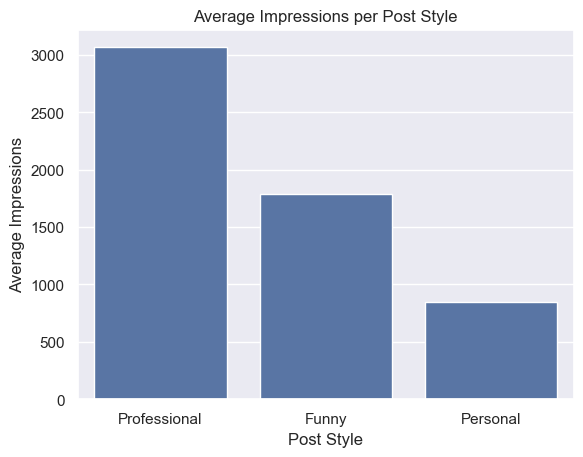

In [28]:
# plotting average impressions per post category
plt.title('Average Impressions per Post Style')
plt.xlabel('Post Style')
plt.ylabel('Average Impressions')
sns.barplot(top_impressions_classified.groupby('style').impressions.mean().sort_values(ascending=False));

In [29]:
# calculating average engagements per post style
top_engagements_classified.groupby('style').engagements.mean().sort_values(ascending=False)

style
Professional    35.266667
Funny           28.318182
Personal        17.500000
Name: engagements, dtype: float64

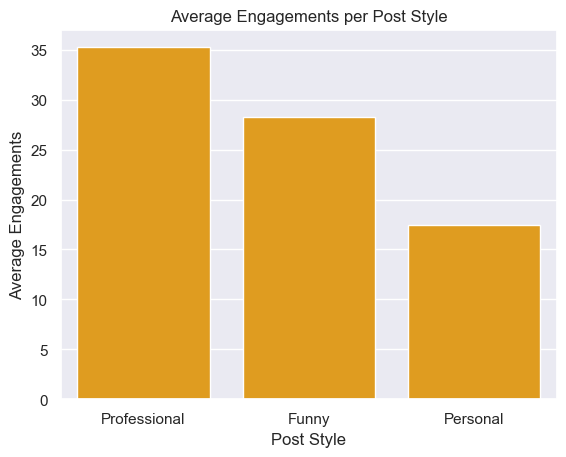

In [30]:
# plotting average engagements per post style
plt.title('Average Engagements per Post Style')
plt.xlabel('Post Style')
plt.ylabel('Average Engagements')
sns.barplot(top_engagements_classified.groupby('style').engagements.mean().sort_values(ascending=False), color='orange');